# Evaluation & Metrics — Complete Analysis
## Gut Microbiome Project · Bar-Ilan University

| Section | Task | Metrics |
|---|---|---|
| 1 | Food Group Classification (10-class) | Accuracy, F1-macro, AUC-ROC, confusion matrix, ROC curves, learning curve |
| 2 | Fermented vs Non-Fermented (binary) | Accuracy, F1, AUC-ROC, Precision-Recall curve |
| 3 | Gut Health Score Regression | R², MAE, RMSE, residual analysis, per-participant |
| 4 | Good vs Bad Gut Day (binary) | Accuracy, F1, AUC-ROC, 5-fold cross-validation |
| 5 | Food Ranking Validation | Bootstrap CIs, significance flags |
| 6 | Overall Summary | All models compared |
| 7 | **Multi-Algorithm Comparison** | RF vs XGBoost vs LightGBM vs Gradient Boosting |
| 8 | **SHAP Interpretability** | Feature importance explained via Shapley values |
| 9 | **FDR Correction** | Benjamini-Hochberg correction on food rankings + Volcano plot |


In [1]:
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from sklearn.ensemble import (
    RandomForestClassifier, RandomForestRegressor,
    GradientBoostingClassifier, GradientBoostingRegressor
)
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import (
    StratifiedKFold, KFold, cross_val_score,
    train_test_split, learning_curve, cross_validate
)
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, roc_auc_score, roc_curve, auc,
    precision_recall_curve, average_precision_score,
    r2_score, mean_absolute_error, mean_squared_error
)
from IPython.display import display

try:
    from xgboost import XGBClassifier, XGBRegressor
    XGB_AVAILABLE = True
except ImportError:
    XGB_AVAILABLE = False

try:
    from lightgbm import LGBMClassifier, LGBMRegressor
    LGB_AVAILABLE = True
except ImportError:
    LGB_AVAILABLE = False

try:
    import shap
    SHAP_AVAILABLE = True
except ImportError:
    SHAP_AVAILABLE = False

try:
    from statsmodels.stats.multitest import multipletests
    STATSMODELS_AVAILABLE = True
except ImportError:
    STATSMODELS_AVAILABLE = False

warnings.filterwarnings('ignore')
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', '{:.4f}'.format)

def find_repo_root():
    for p in [Path.cwd()] + list(Path.cwd().parents):
        if (p / 'master_metadata.tsv').exists():
            return p
    raise FileNotFoundError('Cannot find repo root')

REPO_ROOT = find_repo_root()
DIET_ROOT  = REPO_ROOT / 'dietstudy_analyses-master'
print(f'XGBoost  : {XGB_AVAILABLE}')
print(f'LightGBM : {LGB_AVAILABLE}')
print(f'SHAP     : {SHAP_AVAILABLE}')
print(f'statsmodels: {STATSMODELS_AVAILABLE}')

C:\Users\winte\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


XGBoost  : True
LightGBM : True
SHAP     : True
statsmodels: True


## Data Loading


In [2]:
# Dataset 1
d1 = pd.read_csv(REPO_ROOT / 'features_dataset1.csv', index_col=0)
feat_cols_d1 = [c for c in d1.columns if c not in ['food_group','fermented_binary']]
X1        = d1[feat_cols_d1].fillna(0)
y_group   = d1['food_group']
y_ferment = d1['fermented_binary'].fillna(0).astype(int)
le        = LabelEncoder()
y_grp_enc = le.fit_transform(y_group)

# Dataset 2 — features
d2 = pd.read_csv(REPO_ROOT / 'features_dataset2.csv')
BENEFICIAL  = ['Bifidobacterium','Faecalibacterium','Akkermansia','Lactobacillus']
score_parts = []
for col in [f'dCLR_{t}' for t in BENEFICIAL] + ['Delta_EntTaxa']:
    if col in d2.columns:
        score_parts.append((d2[col]-d2[col].mean())/(d2[col].std()+1e-9))
d2['GutHealthScore'] = pd.concat(score_parts,axis=1).mean(axis=1)
d2['GoodGutDay']     = (d2['GutHealthScore']>0).astype(int)

# Food matrix
FOOD_DIR   = DIET_ROOT / 'data' / 'procrustes' / 'data_username_1day'
MIN_OBS    = 15
logs = []
for fp in sorted(FOOD_DIR.glob('*_food.txt')):
    tmp      = pd.read_csv(fp, sep='\t')
    sid_cols = [c for c in tmp.columns if c not in ['#FoodID','taxonomy']]
    tl = tmp.melt(id_vars=['#FoodID','taxonomy'], value_vars=sid_cols,
                  var_name='PrevSampleID', value_name='Grams')
    tl['Grams'] = pd.to_numeric(tl['Grams'], errors='coerce')
    tl = tl.loc[tl['Grams'] > 0]
    tl['Food_Name'] = tl['taxonomy'].apply(
        lambda t: str(t).split(';')[-1].strip() if pd.notna(t) else 'Unknown')
    logs.append(tl[['PrevSampleID','Food_Name','Grams']])
diet_long = pd.concat(logs, ignore_index=True)
diet_long['PrevSampleID'] = diet_long['PrevSampleID'].astype(str)

valid_prev  = set(d2['PrevSampleID'].astype(str))
diet_long   = diet_long.loc[diet_long['PrevSampleID'].isin(valid_prev)]
food_obs    = diet_long.groupby('Food_Name')['PrevSampleID'].nunique()
common_foods = food_obs[food_obs >= MIN_OBS].index
diet_filt   = diet_long.loc[diet_long['Food_Name'].isin(common_foods)]
food_matrix = (diet_filt.groupby(['PrevSampleID','Food_Name'])['Grams']
               .sum().unstack(fill_value=0))
food_matrix.columns.name = None

d2_str = d2.copy()
d2_str['PrevSampleID'] = d2_str['PrevSampleID'].astype(str)
model_df  = d2_str.join(food_matrix, on='PrevSampleID', how='inner')
food_cols = list(common_foods)
nutr_cols = [c for c in model_df.columns if c.startswith('nutr_')]
X_food    = model_df[food_cols].fillna(0)
X_full    = pd.concat([X_food,
                        model_df[nutr_cols+['Supplement_MCT','StudyDayNo_norm']].fillna(0)],axis=1)
y_score   = model_df['GutHealthScore'].fillna(0)
y_good    = model_df['GoodGutDay'].fillna(0).astype(int)

print(f'D1: {X1.shape}  |  classes: {y_group.nunique()}')
print(f'D2: {X_full.shape}  |  food features: {len(food_cols)}')

D1: (3393, 80)  |  classes: 10
D2: (349, 84)  |  food features: 77


In [3]:
# Shared train/test splits used throughout
X1_tr, X1_te, yg_tr, yg_te = train_test_split(
    X1, y_grp_enc, test_size=0.2, stratify=y_grp_enc, random_state=RANDOM_SEED)
Xf_tr, Xf_te, yf_tr, yf_te = train_test_split(
    X1, y_ferment, test_size=0.2, stratify=y_ferment, random_state=RANDOM_SEED)
X_tr3, X_te3, ys_tr, ys_te = train_test_split(
    X_full, y_score, test_size=0.25, random_state=RANDOM_SEED)
X_tr4, X_te4, yg_tr4, yg_te4 = train_test_split(
    X_full, y_good, test_size=0.25, stratify=y_good, random_state=RANDOM_SEED)
print('Train/test splits ready.')

Train/test splits ready.


---
## Section 1 — Food Group Classification (10-class)


In [4]:
rf1 = RandomForestClassifier(
    n_estimators=400, max_depth=None, class_weight='balanced',
    random_state=RANDOM_SEED, n_jobs=-1)
rf1.fit(X1_tr, yg_tr)
yg_pred  = rf1.predict(X1_te)
yg_proba = rf1.predict_proba(X1_te)

acc1 = accuracy_score(yg_te, yg_pred)
f1m1 = f1_score(yg_te, yg_pred, average='macro')
f1w1 = f1_score(yg_te, yg_pred, average='weighted')
auc1 = roc_auc_score(yg_te, yg_proba, multi_class='ovr', average='macro')

print(f'Accuracy     : {acc1:.4f}')
print(f'F1-macro     : {f1m1:.4f}')
print(f'F1-weighted  : {f1w1:.4f}')
print(f'AUC-ROC (OvR): {auc1:.4f}')
print(classification_report(yg_te, yg_pred, target_names=le.classes_, zero_division=0))

Accuracy     : 0.9249
F1-macro     : 0.8400
F1-weighted  : 0.9198
AUC-ROC (OvR): 0.9938
                         precision    recall  f1-score   support

              Beverages       1.00      0.80      0.89        15
                 Cheese       0.91      0.99      0.94       338
Cocoa / fermented seeds       1.00      1.00      1.00        10
   Fermented vegetables       0.91      0.67      0.77        15
                   Fish       1.00      1.00      1.00        19
                  Kefir       0.97      0.96      0.96       135
                   Meat       1.00      0.96      0.98        53
            Other dairy       0.86      0.55      0.67        55
             Other food       0.89      0.91      0.90        35
                 Yogurt       0.33      0.25      0.29         4

               accuracy                           0.92       679
              macro avg       0.89      0.81      0.84       679
           weighted avg       0.92      0.92      0.92       679


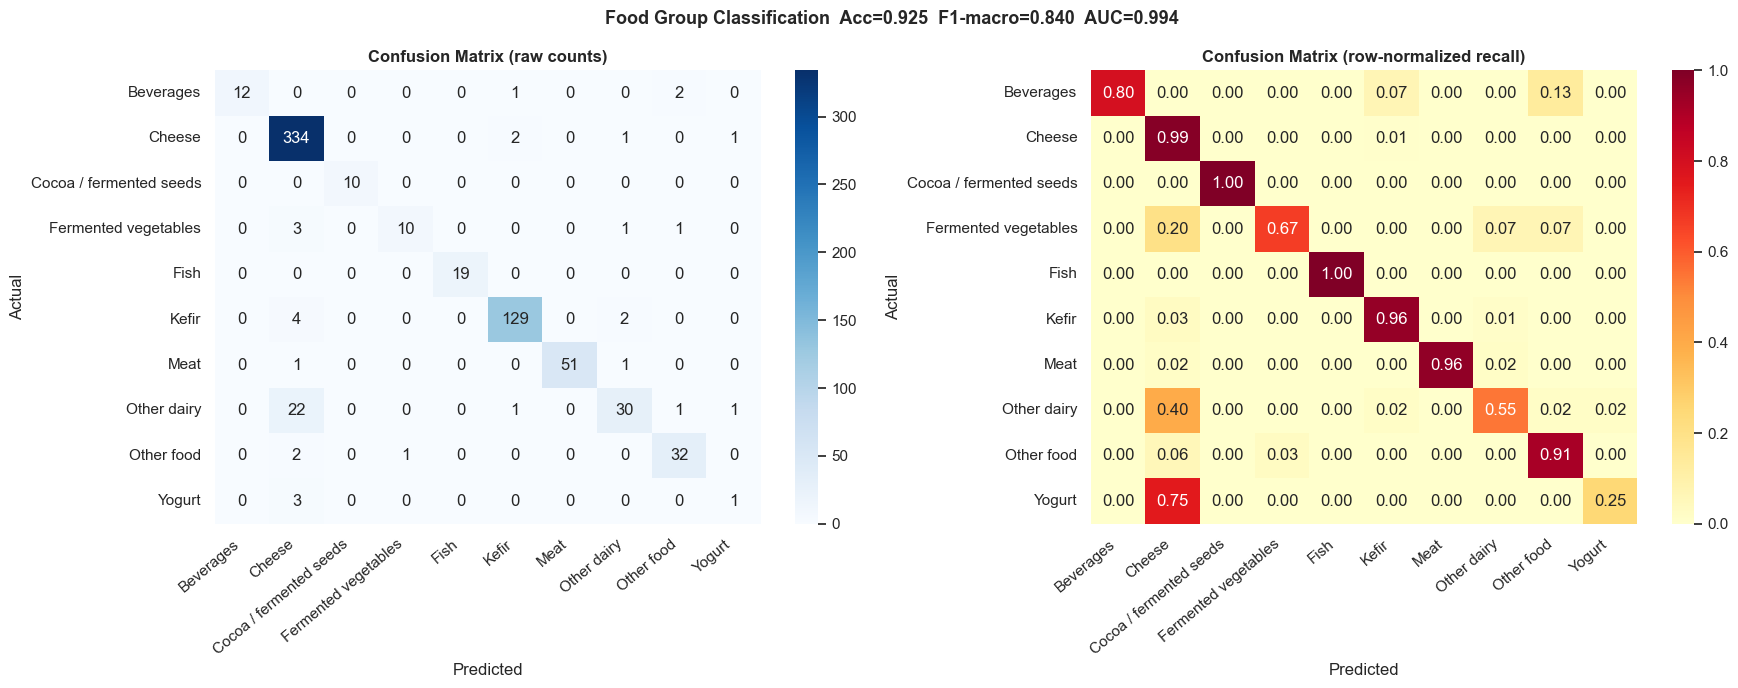

In [5]:
# Confusion matrices
cm1 = confusion_matrix(yg_te, yg_pred)
cm1_norm = cm1.astype(float) / cm1.sum(axis=1, keepdims=True)
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
sns.heatmap(cm1, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=axes[0])
axes[0].set_title('Confusion Matrix (raw counts)', weight='bold')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')
axes[0].set_xticklabels(le.classes_, rotation=40, ha='right')
axes[0].set_yticklabels(le.classes_, rotation=0)
sns.heatmap(cm1_norm, annot=True, fmt='.2f', cmap='YlOrRd',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=axes[1], vmin=0, vmax=1)
axes[1].set_title('Confusion Matrix (row-normalized recall)', weight='bold')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Actual')
axes[1].set_xticklabels(le.classes_, rotation=40, ha='right')
axes[1].set_yticklabels(le.classes_, rotation=0)
plt.suptitle(f'Food Group Classification  Acc={acc1:.3f}  F1-macro={f1m1:.3f}  AUC={auc1:.3f}',
             weight='bold', fontsize=13)
plt.tight_layout(); plt.show()

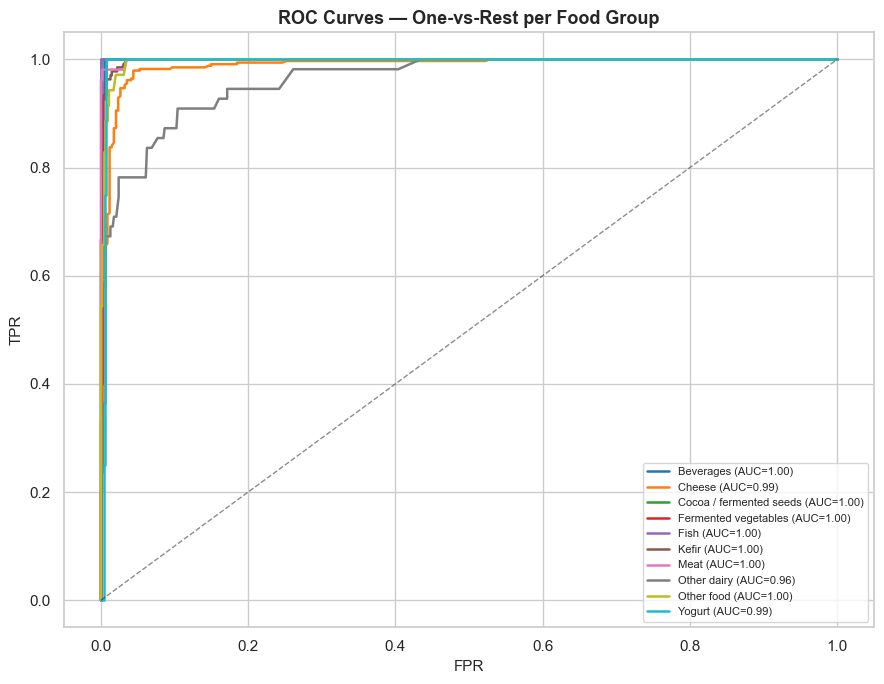

In [6]:
# ROC curves per class
n_classes = len(le.classes_)
yg_bin    = label_binarize(yg_te, classes=list(range(n_classes)))
palette_roc = sns.color_palette('tab10', n_classes)
fig, ax = plt.subplots(figsize=(9, 7))
for i, (cls, color) in enumerate(zip(le.classes_, palette_roc)):
    fpr_i, tpr_i, _ = roc_curve(yg_bin[:, i], yg_proba[:, i])
    ax.plot(fpr_i, tpr_i, color=color, lw=1.8,
            label=f'{cls} (AUC={auc(fpr_i,tpr_i):.2f})')
ax.plot([0,1],[0,1],'k--',lw=1,alpha=0.5)
ax.set_xlabel('FPR', fontsize=11); ax.set_ylabel('TPR', fontsize=11)
ax.set_title('ROC Curves — One-vs-Rest per Food Group', weight='bold', fontsize=13)
ax.legend(fontsize=8, loc='lower right')
plt.tight_layout(); plt.show()

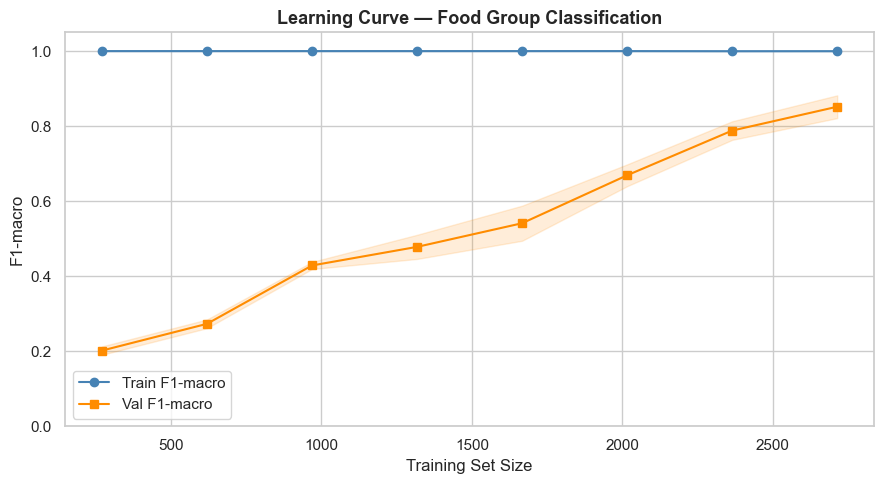

In [7]:
# Learning curve
train_sizes, tr_sc, va_sc = learning_curve(
    RandomForestClassifier(n_estimators=200, class_weight='balanced',
                            random_state=RANDOM_SEED, n_jobs=-1),
    X1, y_grp_enc,
    cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_SEED),
    scoring='f1_macro', train_sizes=np.linspace(0.1, 1.0, 8), n_jobs=-1)
fig, ax = plt.subplots(figsize=(9, 5))
ax.fill_between(train_sizes, tr_sc.mean(1)-tr_sc.std(1),
                tr_sc.mean(1)+tr_sc.std(1), alpha=0.15, color='steelblue')
ax.fill_between(train_sizes, va_sc.mean(1)-va_sc.std(1),
                va_sc.mean(1)+va_sc.std(1), alpha=0.15, color='darkorange')
ax.plot(train_sizes, tr_sc.mean(1), 'o-', color='steelblue',   label='Train F1-macro')
ax.plot(train_sizes, va_sc.mean(1), 's-', color='darkorange', label='Val F1-macro')
ax.set_xlabel('Training Set Size'); ax.set_ylabel('F1-macro')
ax.set_title('Learning Curve — Food Group Classification', weight='bold', fontsize=13)
ax.legend(); ax.set_ylim(0, 1.05)
plt.tight_layout(); plt.show()

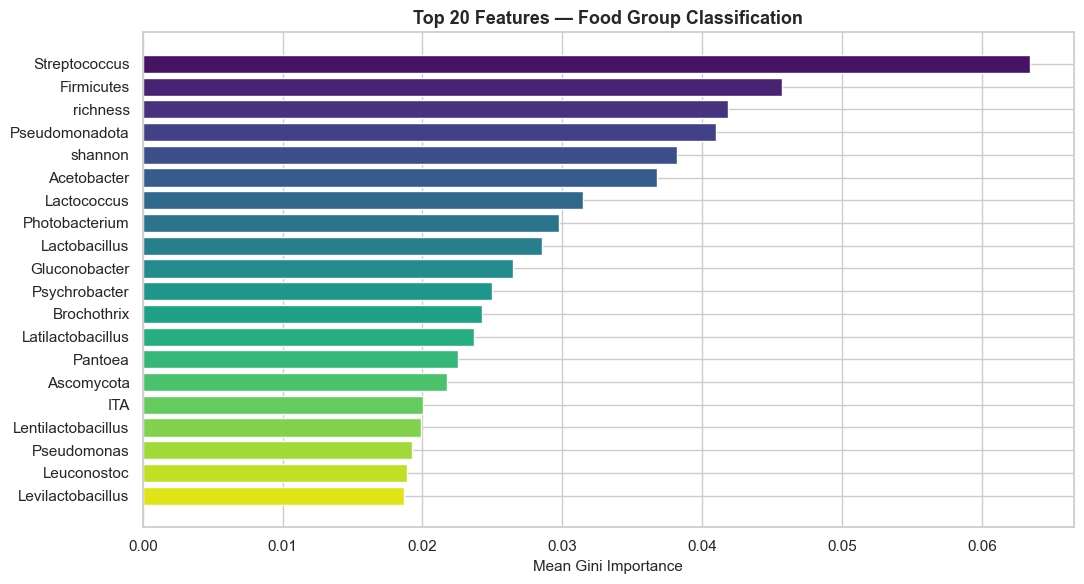

In [8]:
# Feature importance — top 20
imp_d1 = pd.Series(rf1.feature_importances_, index=X1.columns).sort_values(ascending=False)
top20  = imp_d1.head(20)
def short_label(n):
    for p in ['genus_','phylum_','country_','div_']:
        if n.startswith(p): return n.replace(p,'').replace('_',' ')[:30]
    return n[:30]
fig, ax = plt.subplots(figsize=(11, 6))
colors_imp = sns.color_palette('viridis_r', 20)
ax.barh([short_label(n) for n in top20.index[::-1]], top20.values[::-1], color=colors_imp)
ax.set_xlabel('Mean Gini Importance', fontsize=11)
ax.set_title('Top 20 Features — Food Group Classification', weight='bold', fontsize=13)
plt.tight_layout(); plt.show()

---
## Section 2 — Fermented vs Non-Fermented


Accuracy: 1.0000  F1-macro: 1.0000  AUC: nan
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       679

    accuracy                           1.00       679
   macro avg       1.00      1.00      1.00       679
weighted avg       1.00      1.00      1.00       679



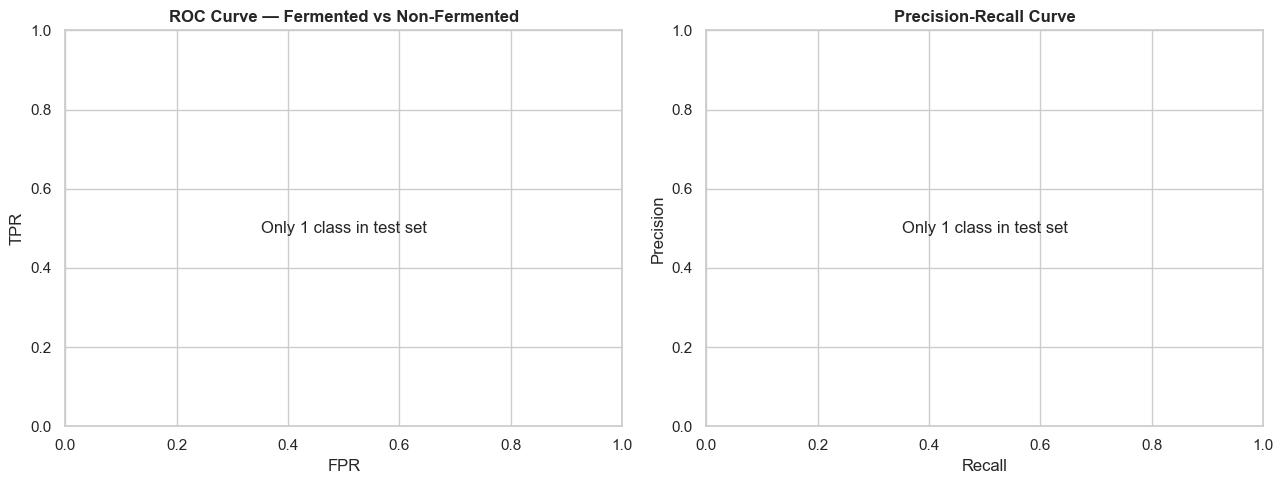

In [9]:
rf_bin = RandomForestClassifier(
    n_estimators=400, class_weight='balanced',
    random_state=RANDOM_SEED, n_jobs=-1)
rf_bin.fit(Xf_tr, yf_tr)
yf_pred  = rf_bin.predict(Xf_te)
_proba   = rf_bin.predict_proba(Xf_te)
yf_proba = _proba[:, 1] if _proba.shape[1] >= 2 else _proba[:, 0]
has2cls  = (len(np.unique(yf_te)) == 2) and (_proba.shape[1] >= 2)
acc_f    = accuracy_score(yf_te, yf_pred)
f1_f     = f1_score(yf_te, yf_pred, average='macro', zero_division=0)
auc_f    = roc_auc_score(yf_te, yf_proba) if has2cls else float('nan')
print(f'Accuracy: {acc_f:.4f}  F1-macro: {f1_f:.4f}  AUC: {auc_f:.4f}')
print(classification_report(yf_te, yf_pred, zero_division=0))
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
if has2cls:
    fpr_f,tpr_f,_ = roc_curve(yf_te, yf_proba)
    axes[0].plot(fpr_f, tpr_f, lw=2, label=f'AUC={auc_f:.3f}')
    axes[0].plot([0,1],[0,1],'k--',lw=1); axes[0].legend()
    prec_f,rec_f,_ = precision_recall_curve(yf_te, yf_proba)
    ap_f = average_precision_score(yf_te, yf_proba)
    axes[1].plot(rec_f, prec_f, lw=2, color='darkorange', label=f'AP={ap_f:.3f}')
    axes[1].axhline(y_ferment.mean(), color='gray', linestyle='--',
                    label=f'Baseline={y_ferment.mean():.3f}')
    axes[1].legend()
else:
    for ax in axes: ax.text(0.5,0.5,'Only 1 class in test set',ha='center',va='center')
axes[0].set_title('ROC Curve — Fermented vs Non-Fermented', weight='bold')
axes[1].set_title('Precision-Recall Curve', weight='bold')
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
plt.tight_layout(); plt.show()

---
## Section 3 — Gut Health Score Regression


R²=-0.1105  MAE=0.3550  RMSE=0.4419  Pearson r=-0.1118 (p=0.2998)


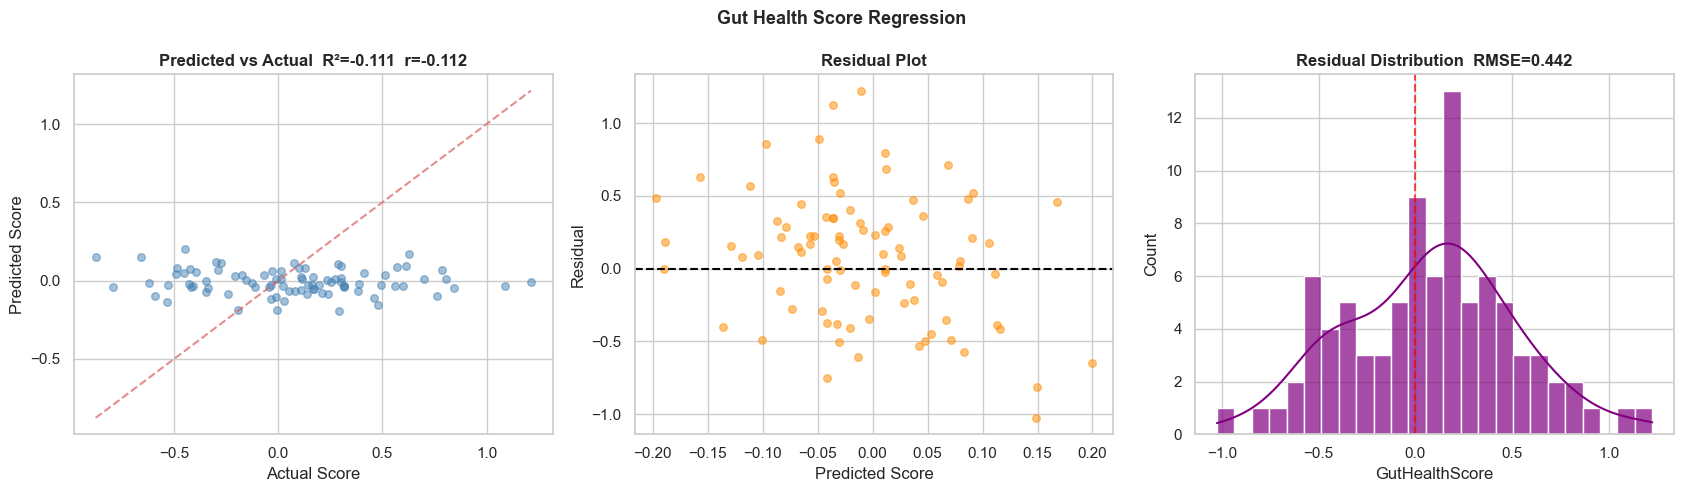

In [10]:
rf_reg = RandomForestRegressor(
    n_estimators=500, max_depth=6, min_samples_leaf=3,
    random_state=RANDOM_SEED, n_jobs=-1)
rf_reg.fit(X_tr3, ys_tr)
ys_pred = rf_reg.predict(X_te3)
r2_val  = r2_score(ys_te, ys_pred)
mae_val = mean_absolute_error(ys_te, ys_pred)
rmse_val= np.sqrt(mean_squared_error(ys_te, ys_pred))
pr, pp  = stats.pearsonr(ys_te, ys_pred)
residuals = ys_te - ys_pred
print(f'R²={r2_val:.4f}  MAE={mae_val:.4f}  RMSE={rmse_val:.4f}  Pearson r={pr:.4f} (p={pp:.4f})')
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
lims = [min(float(ys_te.min()),float(ys_pred.min())),
        max(float(ys_te.max()),float(ys_pred.max()))]
axes[0].scatter(ys_te, ys_pred, alpha=0.5, s=30, color='steelblue')
axes[0].plot(lims, lims, 'r--', lw=1.5, alpha=0.7)
axes[0].set_xlabel('Actual Score'); axes[0].set_ylabel('Predicted Score')
axes[0].set_title(f'Predicted vs Actual  R²={r2_val:.3f}  r={pr:.3f}', weight='bold')
axes[1].scatter(ys_pred, residuals, alpha=0.5, s=30, color='darkorange')
axes[1].axhline(0,color='black',lw=1.5,linestyle='--')
axes[1].set_xlabel('Predicted Score'); axes[1].set_ylabel('Residual')
axes[1].set_title('Residual Plot', weight='bold')
sns.histplot(residuals, bins=25, kde=True, ax=axes[2], color='purple', alpha=0.7)
axes[2].axvline(0, color='red', linestyle='--', alpha=0.7)
axes[2].set_title(f'Residual Distribution  RMSE={rmse_val:.3f}', weight='bold')
plt.suptitle('Gut Health Score Regression', weight='bold', fontsize=13)
plt.tight_layout(); plt.show()

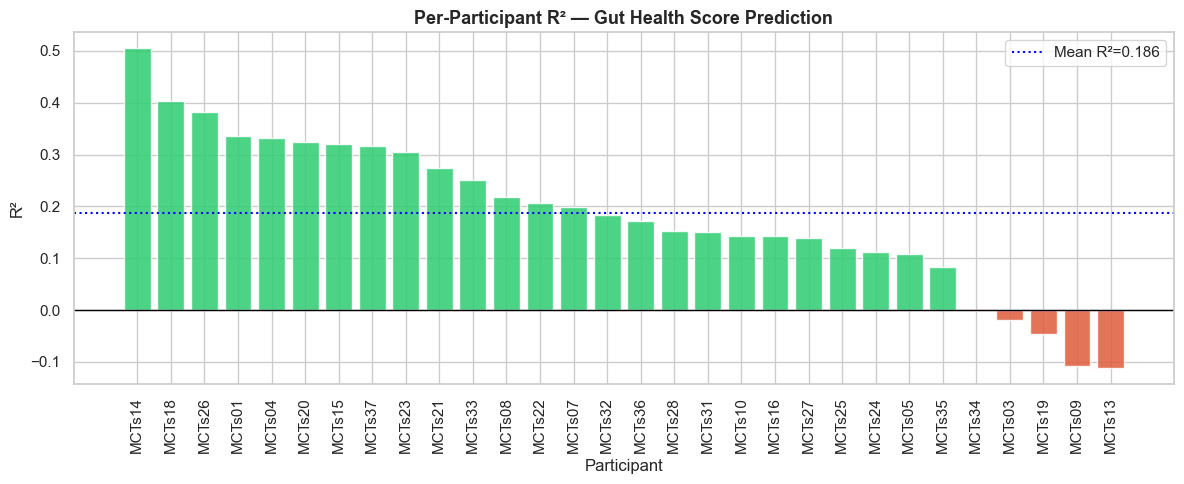

R² > 0: 25 / 30 participants


In [11]:
# Per-participant R²
model_df2 = model_df.copy()
model_df2['predicted_score'] = rf_reg.predict(X_full.loc[model_df.index])
per_part = []
for user, grp in model_df2.groupby('UserName'):
    if len(grp) < 4: continue
    per_part.append({'UserName': user, 'N': len(grp),
                     'R2': r2_score(grp['GutHealthScore'],grp['predicted_score']),
                     'MAE': mean_absolute_error(grp['GutHealthScore'],grp['predicted_score'])})
pp_df = pd.DataFrame(per_part).sort_values('R2', ascending=False)
fig, ax = plt.subplots(figsize=(12, 5))
colors_pp = ['#2ecc71' if r >= 0 else '#e05c3a' for r in pp_df['R2']]
ax.bar(pp_df['UserName'], pp_df['R2'], color=colors_pp, alpha=0.85)
ax.axhline(0, color='black', lw=1); ax.axhline(pp_df['R2'].mean(), color='blue',
    lw=1.5, linestyle=':', label=f"Mean R²={pp_df['R2'].mean():.3f}")
ax.set_xlabel('Participant'); ax.set_ylabel('R²')
ax.set_title('Per-Participant R² — Gut Health Score Prediction', weight='bold', fontsize=13)
ax.legend(); plt.xticks(rotation=90); plt.tight_layout(); plt.show()
print(f"R² > 0: {(pp_df['R2']>0).sum()} / {len(pp_df)} participants")

---
## Section 4 — Good vs Bad Gut Day (Binary Classification)


Hold-out  Acc=0.4318  F1=0.4244  AUC=0.3874
5-fold CV Acc=0.4643+/-0.0519
5-fold CV F1 =0.4583+/-0.0549
5-fold CV AUC=0.4558+/-0.0482


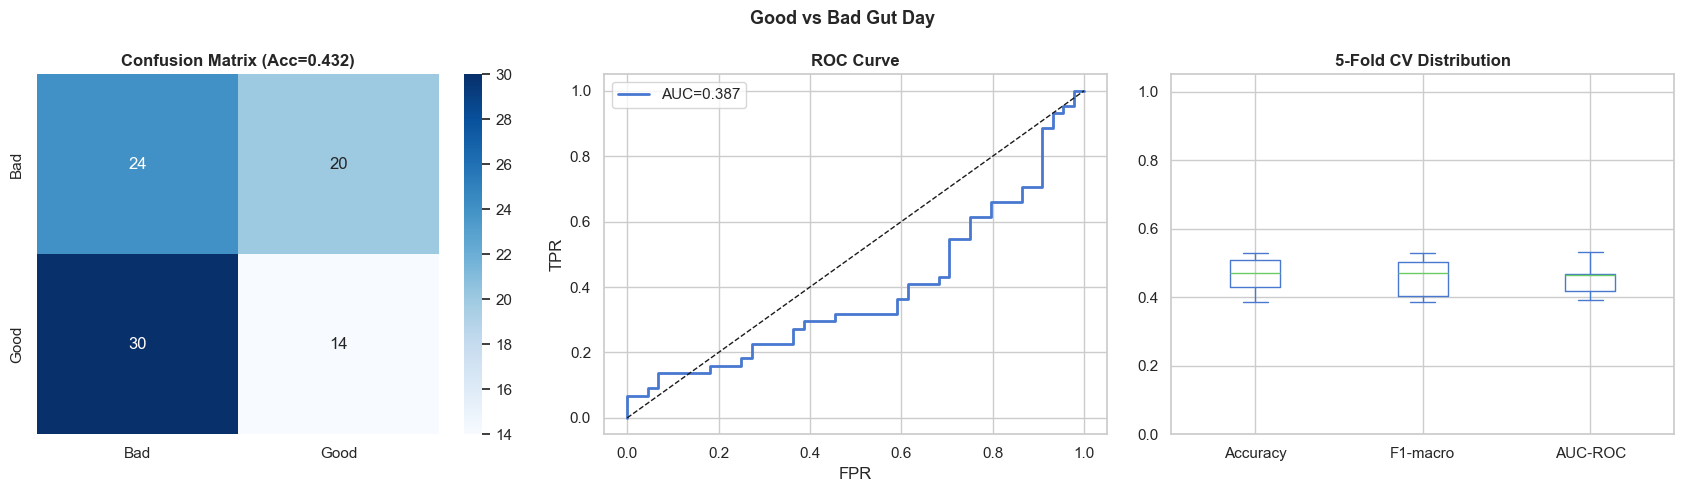

In [12]:
rf_cls2 = RandomForestClassifier(
    n_estimators=500, max_depth=6, class_weight='balanced',
    min_samples_leaf=3, random_state=RANDOM_SEED, n_jobs=-1)
rf_cls2.fit(X_tr4, yg_tr4)
yg_pred2  = rf_cls2.predict(X_te4)
yg_proba2 = rf_cls2.predict_proba(X_te4)[:, 1]
acc4  = accuracy_score(yg_te4, yg_pred2)
f14   = f1_score(yg_te4, yg_pred2, average='macro', zero_division=0)
auc4  = roc_auc_score(yg_te4, yg_proba2)
ap4   = average_precision_score(yg_te4, yg_proba2)
cv4   = StratifiedKFold(5, shuffle=True, random_state=RANDOM_SEED)
cv4_acc = cross_val_score(rf_cls2, X_full, y_good, cv=cv4, scoring='accuracy', n_jobs=-1)
cv4_f1  = cross_val_score(rf_cls2, X_full, y_good, cv=cv4, scoring='f1_macro',  n_jobs=-1)
cv4_auc = cross_val_score(rf_cls2, X_full, y_good, cv=cv4, scoring='roc_auc',   n_jobs=-1)
print(f'Hold-out  Acc={acc4:.4f}  F1={f14:.4f}  AUC={auc4:.4f}')
print(f'5-fold CV Acc={cv4_acc.mean():.4f}+/-{cv4_acc.std():.4f}')
print(f'5-fold CV F1 ={cv4_f1.mean():.4f}+/-{cv4_f1.std():.4f}')
print(f'5-fold CV AUC={cv4_auc.mean():.4f}+/-{cv4_auc.std():.4f}')
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
cm4 = confusion_matrix(yg_te4, yg_pred2)
sns.heatmap(cm4, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Bad','Good'], yticklabels=['Bad','Good'], ax=axes[0])
axes[0].set_title(f'Confusion Matrix (Acc={acc4:.3f})', weight='bold')
fpr4,tpr4,_ = roc_curve(yg_te4, yg_proba2)
axes[1].plot(fpr4, tpr4, lw=2, label=f'AUC={auc4:.3f}')
axes[1].plot([0,1],[0,1],'k--',lw=1); axes[1].legend()
axes[1].set_title('ROC Curve', weight='bold')
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
cv_df = pd.DataFrame({'Accuracy':cv4_acc,'F1-macro':cv4_f1,'AUC-ROC':cv4_auc})
cv_df.plot(kind='box', ax=axes[2])
axes[2].set_title('5-Fold CV Distribution', weight='bold'); axes[2].set_ylim(0,1.05)
plt.suptitle('Good vs Bad Gut Day', weight='bold', fontsize=13)
plt.tight_layout(); plt.show()

---
## Section 5 — Food Ranking with Bootstrap Confidence Intervals


Computing bootstrap CIs...


Significant (CI not crossing 0): 2 foods


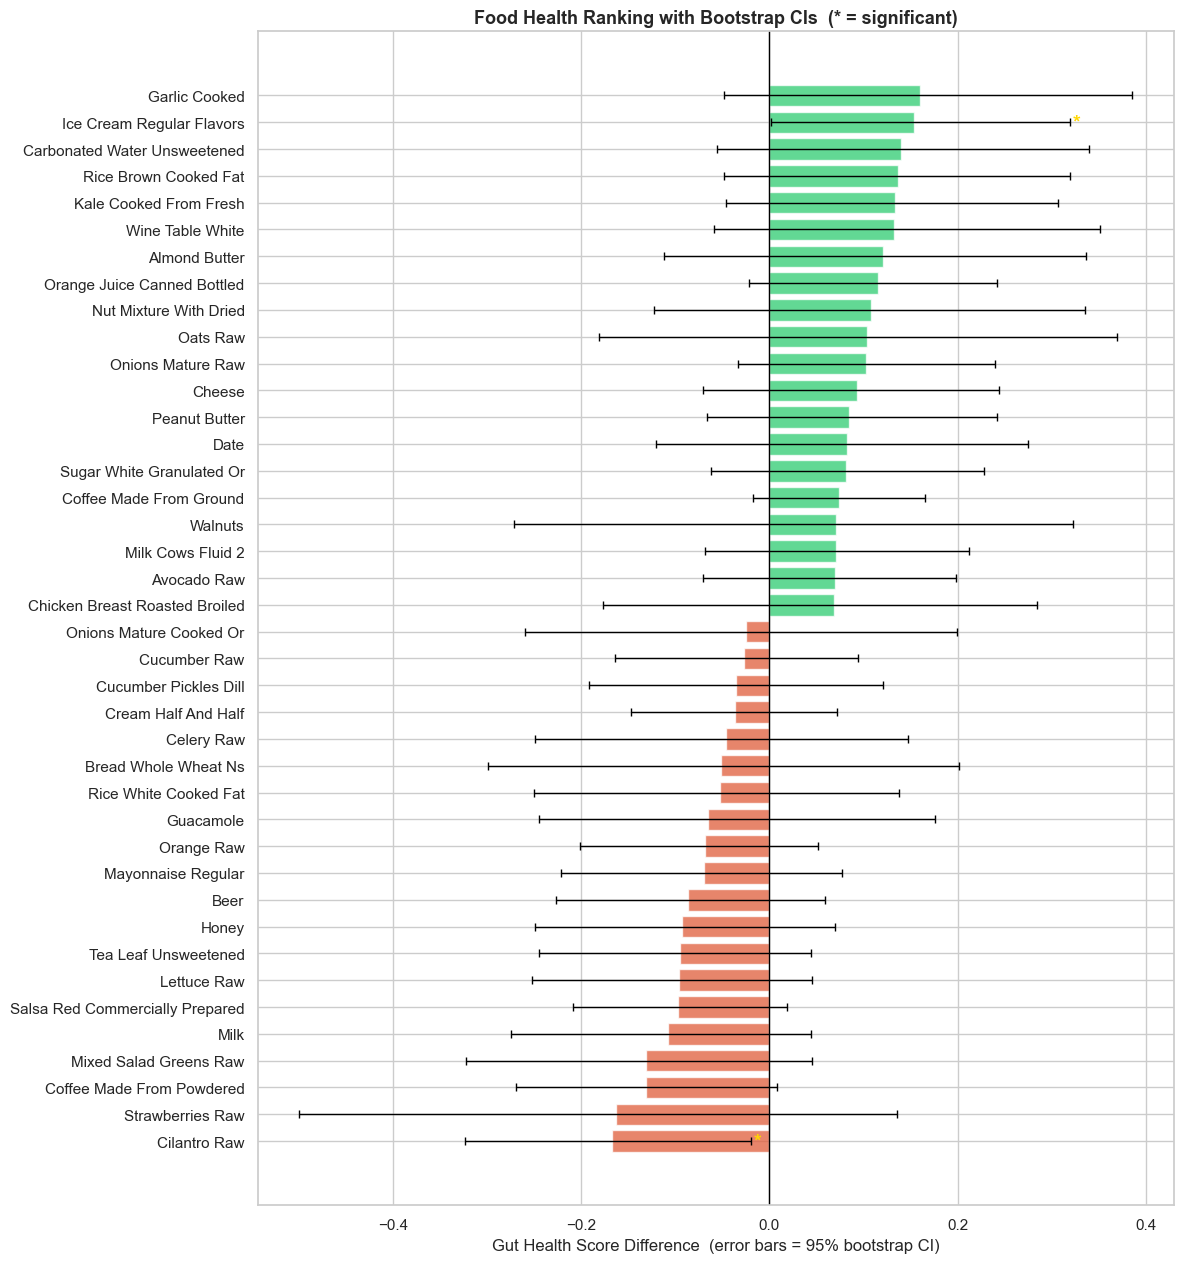

In [13]:
N_BOOT = 1000
def bootstrap_diff(data, food_col, score_col, n_boot=N_BOOT, seed=RANDOM_SEED):
    rng   = np.random.default_rng(seed)
    diffs = []
    for _ in range(n_boot):
        s    = data.sample(n=len(data), replace=True,
                            random_state=int(rng.integers(1e6)))
        mask = s[food_col] > 0
        if mask.sum() < 3 or (~mask).sum() < 3: continue
        diffs.append(s.loc[mask,score_col].mean() - s.loc[~mask,score_col].mean())
    return np.array(diffs)

print('Computing bootstrap CIs...')
boot_results = []
for food in food_cols:
    mask = model_df[food] > 0
    if mask.sum() < 5: continue
    diffs = bootstrap_diff(model_df[[food,'GutHealthScore']], food, 'GutHealthScore')
    if len(diffs) == 0: continue
    ci_lo, ci_hi = np.percentile(diffs, [2.5, 97.5])
    obs = model_df.loc[mask,'GutHealthScore'].mean() - model_df.loc[~mask,'GutHealthScore'].mean()
    boot_results.append(dict(food=food,
        label=' '.join(food.replace('_NFS','').split('_')[:4]).title(),
        obs_diff=obs, ci_lo=ci_lo, ci_hi=ci_hi,
        significant=(ci_lo>0)or(ci_hi<0)))

boot_df = pd.DataFrame(boot_results).sort_values('obs_diff', ascending=False)
sig_foods = boot_df[boot_df['significant']]
print(f'Significant (CI not crossing 0): {len(sig_foods)} foods')

plot_b = pd.concat([boot_df.head(20), boot_df.tail(20)]).drop_duplicates('food').sort_values('obs_diff')
fig, ax = plt.subplots(figsize=(12, max(8, 0.32*len(plot_b))))
colors_b = ['#e05c3a' if v < 0 else '#2ecc71' for v in plot_b['obs_diff']]
ax.barh(plot_b['label'], plot_b['obs_diff'], color=colors_b, alpha=0.75)
ax.errorbar(plot_b['obs_diff'], range(len(plot_b)),
    xerr=[plot_b['obs_diff']-plot_b['ci_lo'], plot_b['ci_hi']-plot_b['obs_diff']],
    fmt='none', color='black', capsize=3, linewidth=1)
ax.axvline(0, color='black', lw=1)
for i, (_, row) in enumerate(plot_b.iterrows()):
    if row['significant']:
        ax.text(row['ci_hi']+0.003, i, '*', va='center', fontsize=14,
                color='gold', fontweight='bold')
ax.set_xlabel('Gut Health Score Difference  (error bars = 95% bootstrap CI)')
ax.set_title('Food Health Ranking with Bootstrap CIs  (* = significant)', weight='bold', fontsize=13)
plt.tight_layout(); plt.show()
boot_df.to_csv(REPO_ROOT / 'food_ranking_bootstrap.csv', index=False)

---
## Section 6 — Random Forest Baseline Summary


In [14]:
baseline_df = pd.DataFrame([
    {'Task':'Food Group (D1)','Type':'10-class','Accuracy':f'{acc1:.4f}',
     'F1-macro':f'{f1m1:.4f}','AUC-ROC':f'{auc1:.4f}'},
    {'Task':'Fermented (D1)','Type':'Binary','Accuracy':f'{acc_f:.4f}',
     'F1-macro':f'{f1_f:.4f}','AUC-ROC':f'{auc_f:.4f}'},
    {'Task':'Gut Score Regression (D2)','Type':'Regression',
     'Accuracy':f'R2={r2_val:.4f}','F1-macro':f'MAE={mae_val:.4f}',
     'AUC-ROC':f'RMSE={rmse_val:.4f}'},
    {'Task':'Good/Bad Gut Day (D2)','Type':'Binary','Accuracy':f'{acc4:.4f}',
     'F1-macro':f'{f14:.4f}','AUC-ROC':f'{auc4:.4f}'},
])
print('=== RANDOM FOREST BASELINE RESULTS ===')
display(baseline_df)

=== RANDOM FOREST BASELINE RESULTS ===


,Task,Type,Accuracy,F1-macro,AUC-ROC
0,Food Group (D1),10-class,0.9249,0.8400,0.9938
1,Fermented (D1),Binary,1.0000,1.0000,nan
2,Gut Score Regression (D2),Regression,R2=-0.1105,MAE=0.3550,RMSE=0.4419
3,Good/Bad Gut Day (D2),Binary,0.4318,0.4244,0.3874


---
## Section 7 — Multi-Algorithm Comparison

We compare **Random Forest**, **Gradient Boosting** (sklearn), **XGBoost**, and **LightGBM** across all three tasks using 5-fold cross-validation.


In [15]:
# Build algorithm zoo
def make_classifiers_10class():
    clfs = {
        'Random Forest': RandomForestClassifier(
            n_estimators=300, class_weight='balanced',
            random_state=RANDOM_SEED, n_jobs=-1),
        'Gradient Boosting': GradientBoostingClassifier(
            n_estimators=200, max_depth=5,
            learning_rate=0.1, random_state=RANDOM_SEED),
    }
    if XGB_AVAILABLE:
        clfs['XGBoost'] = XGBClassifier(
            n_estimators=300, max_depth=6, learning_rate=0.1,
            random_state=RANDOM_SEED, n_jobs=-1, verbosity=0,
            eval_metric='mlogloss')
    if LGB_AVAILABLE:
        clfs['LightGBM'] = LGBMClassifier(
            n_estimators=300, max_depth=6, learning_rate=0.1,
            class_weight='balanced', random_state=RANDOM_SEED,
            n_jobs=-1, verbose=-1)
    return clfs

def make_classifiers_binary():
    clfs = {
        'Random Forest': RandomForestClassifier(
            n_estimators=300, class_weight='balanced',
            max_depth=6, min_samples_leaf=3,
            random_state=RANDOM_SEED, n_jobs=-1),
        'Gradient Boosting': GradientBoostingClassifier(
            n_estimators=200, max_depth=4,
            learning_rate=0.1, random_state=RANDOM_SEED),
    }
    if XGB_AVAILABLE:
        clfs['XGBoost'] = XGBClassifier(
            n_estimators=300, max_depth=6, learning_rate=0.1,
            random_state=RANDOM_SEED, n_jobs=-1, verbosity=0,
            scale_pos_weight=(y_good==0).sum()/(y_good==1).sum())
    if LGB_AVAILABLE:
        clfs['LightGBM'] = LGBMClassifier(
            n_estimators=300, max_depth=6, learning_rate=0.1,
            class_weight='balanced', random_state=RANDOM_SEED,
            n_jobs=-1, verbose=-1)
    return clfs

def make_regressors():
    regs = {
        'Random Forest': RandomForestRegressor(
            n_estimators=300, max_depth=6, min_samples_leaf=3,
            random_state=RANDOM_SEED, n_jobs=-1),
        'Gradient Boosting': GradientBoostingRegressor(
            n_estimators=200, max_depth=4,
            learning_rate=0.1, random_state=RANDOM_SEED),
    }
    if XGB_AVAILABLE:
        regs['XGBoost'] = XGBRegressor(
            n_estimators=300, max_depth=6, learning_rate=0.1,
            random_state=RANDOM_SEED, n_jobs=-1, verbosity=0)
    if LGB_AVAILABLE:
        regs['LightGBM'] = LGBMRegressor(
            n_estimators=300, max_depth=6, learning_rate=0.1,
            random_state=RANDOM_SEED, n_jobs=-1, verbose=-1)
    return regs

cv5 = StratifiedKFold(5, shuffle=True, random_state=RANDOM_SEED)
cv5r = KFold(5, shuffle=True, random_state=RANDOM_SEED)
print('Model definitions ready.')

Model definitions ready.


In [16]:
# Task A: Food Group Classification (10-class)
print('Task A: Food Group Classification (10-class) — 5-fold CV...')
task_a_results = {}
for name, clf in make_classifiers_10class().items():
    print(f'  Training {name}...')
    cv_f1  = cross_val_score(clf, X1, y_grp_enc, cv=cv5, scoring='f1_macro',   n_jobs=-1)
    cv_acc = cross_val_score(clf, X1, y_grp_enc, cv=cv5, scoring='accuracy',   n_jobs=-1)
    task_a_results[name] = {'F1-macro_mean': cv_f1.mean(), 'F1-macro_std': cv_f1.std(),
                             'Accuracy_mean': cv_acc.mean(),'Accuracy_std': cv_acc.std()}
    print(f'    F1-macro={cv_f1.mean():.4f}+/-{cv_f1.std():.4f}  Acc={cv_acc.mean():.4f}')
ta_df = pd.DataFrame(task_a_results).T
display(ta_df.round(4))

Task A: Food Group Classification (10-class) — 5-fold CV...
  Training Random Forest...


    F1-macro=0.8475+/-0.0246  Acc=0.9210
  Training Gradient Boosting...


    F1-macro=0.8056+/-0.0171  Acc=0.9116
  Training XGBoost...


    F1-macro=0.8836+/-0.0158  Acc=0.9352
  Training LightGBM...


    F1-macro=0.8947+/-0.0196  Acc=0.9408


,F1-macro_mean,F1-macro_std,Accuracy_mean,Accuracy_std
Random Forest,0.8475,0.0246,0.9210,0.0097
Gradient Boosting,0.8056,0.0171,0.9116,0.0081
XGBoost,0.8836,0.0158,0.9352,0.0043
LightGBM,0.8947,0.0196,0.9408,0.0068


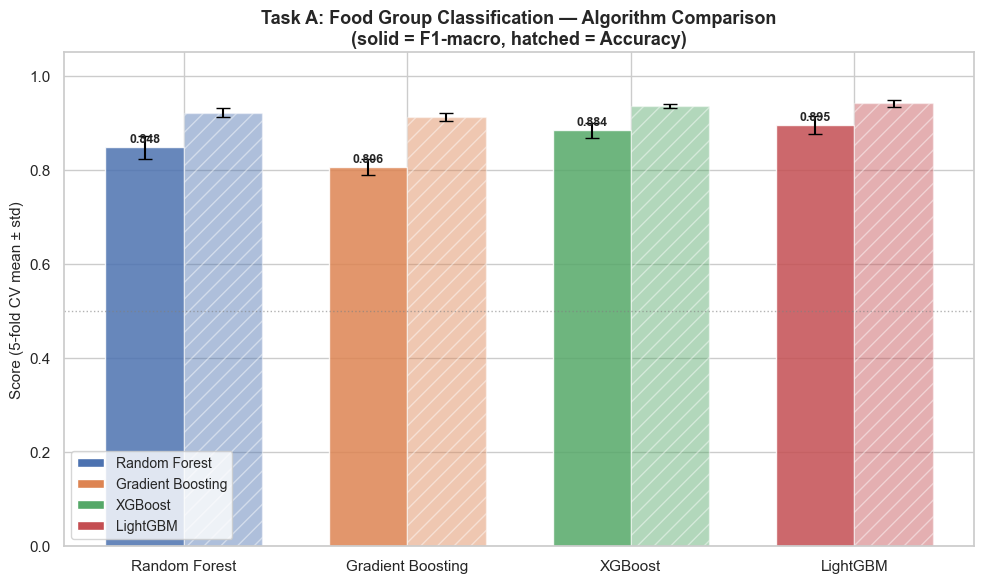

In [17]:
# Visualize Task A
names_a = list(task_a_results.keys())
f1_means = [task_a_results[n]['F1-macro_mean'] for n in names_a]
f1_stds  = [task_a_results[n]['F1-macro_std']  for n in names_a]
ac_means = [task_a_results[n]['Accuracy_mean'] for n in names_a]
ac_stds  = [task_a_results[n]['Accuracy_std']  for n in names_a]

x = np.arange(len(names_a))
w = 0.35
palette_cmp = ['#4C72B0','#DD8452','#55A868','#C44E52']

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - w/2, f1_means, w, yerr=f1_stds, capsize=5,
               label='F1-macro', color=[palette_cmp[i] for i in range(len(names_a))],
               alpha=0.85, error_kw=dict(ecolor='black', lw=1.5))
bars2 = ax.bar(x + w/2, ac_means, w, yerr=ac_stds, capsize=5,
               label='Accuracy', color=[palette_cmp[i] for i in range(len(names_a))],
               alpha=0.45, hatch='//', error_kw=dict(ecolor='black', lw=1.5))
for bar in bars1:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(names_a, fontsize=11)
ax.set_ylim(0, 1.05); ax.set_ylabel('Score (5-fold CV mean ± std)', fontsize=11)
ax.set_title('Task A: Food Group Classification — Algorithm Comparison\n'
             '(solid = F1-macro, hatched = Accuracy)', weight='bold', fontsize=13)

# Add legend patches
from matplotlib.patches import Patch
legend_elems = [Patch(facecolor=palette_cmp[i], label=names_a[i]) for i in range(len(names_a))]
ax.legend(handles=legend_elems, fontsize=10)
ax.axhline(0.5, color='gray', linestyle=':', lw=1, alpha=0.6, label='0.5 baseline')
plt.tight_layout(); plt.show()

Task B: Gut Health Score Regression — 5-fold CV...
  Training Random Forest...


    R2=-0.1770+/-0.1316  MAE=0.3575
  Training Gradient Boosting...


    R2=-0.5237+/-0.2046  MAE=0.4092
  Training XGBoost...


    R2=-0.4144+/-0.1611  MAE=0.4025
  Training LightGBM...


    R2=-0.5720+/-0.3043  MAE=0.4258


,R2_mean,R2_std,MAE_mean,MAE_std
Random Forest,-0.1770,0.1316,0.3575,0.0157
Gradient Boosting,-0.5237,0.2046,0.4092,0.0205
XGBoost,-0.4144,0.1611,0.4025,0.0219
LightGBM,-0.5720,0.3043,0.4258,0.0279


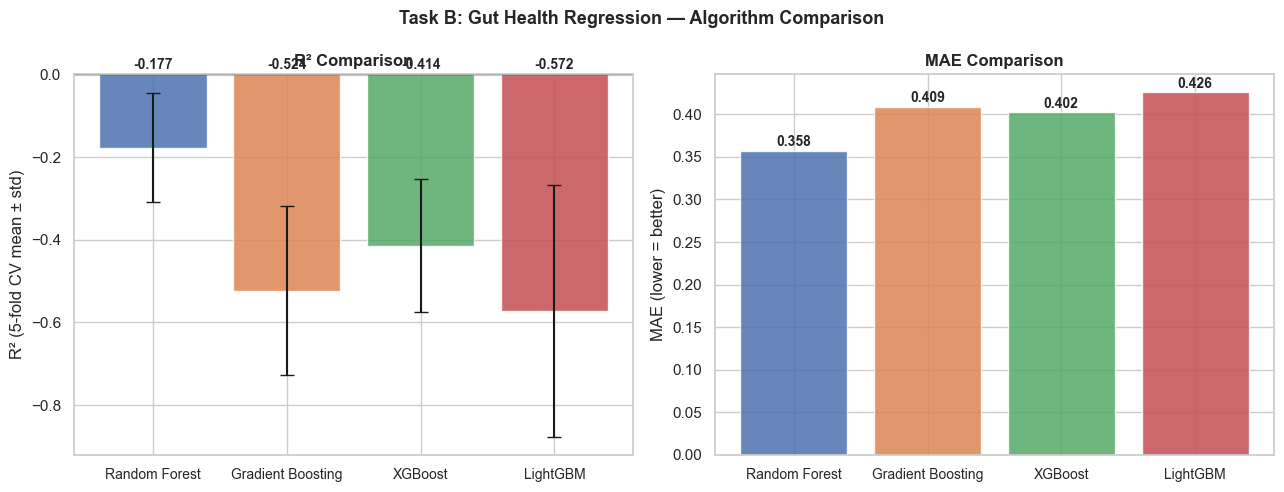

In [18]:
# Task B: Gut Health Regression
print('Task B: Gut Health Score Regression — 5-fold CV...')
task_b_results = {}
for name, reg in make_regressors().items():
    print(f'  Training {name}...')
    cv_r2  = cross_val_score(reg, X_full, y_score, cv=cv5r, scoring='r2', n_jobs=-1)
    cv_mae = cross_val_score(reg, X_full, y_score, cv=cv5r,
                              scoring='neg_mean_absolute_error', n_jobs=-1)
    task_b_results[name] = {'R2_mean': cv_r2.mean(), 'R2_std': cv_r2.std(),
                             'MAE_mean': -cv_mae.mean(),'MAE_std': cv_mae.std()}
    print(f'    R2={cv_r2.mean():.4f}+/-{cv_r2.std():.4f}  MAE={-cv_mae.mean():.4f}')
tb_df = pd.DataFrame(task_b_results).T
display(tb_df.round(4))

names_b  = list(task_b_results.keys())
r2_means = [task_b_results[n]['R2_mean']  for n in names_b]
r2_stds  = [task_b_results[n]['R2_std']   for n in names_b]
mae_means= [task_b_results[n]['MAE_mean'] for n in names_b]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
xb = np.arange(len(names_b))
axes[0].bar(xb, r2_means, yerr=r2_stds, capsize=5,
            color=[palette_cmp[i] for i in range(len(names_b))], alpha=0.85)
for i, v in enumerate(r2_means):
    axes[0].text(i, max(v,0)+0.005, f'{v:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[0].set_xticks(xb); axes[0].set_xticklabels(names_b, fontsize=10)
axes[0].axhline(0, color='black', lw=1)
axes[0].set_ylabel('R² (5-fold CV mean ± std)'); axes[0].set_title('R² Comparison', weight='bold')

axes[1].bar(xb, mae_means, color=[palette_cmp[i] for i in range(len(names_b))], alpha=0.85)
for i, v in enumerate(mae_means):
    axes[1].text(i, v+0.002, f'{v:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[1].set_xticks(xb); axes[1].set_xticklabels(names_b, fontsize=10)
axes[1].set_ylabel('MAE (lower = better)'); axes[1].set_title('MAE Comparison', weight='bold')
plt.suptitle('Task B: Gut Health Regression — Algorithm Comparison', weight='bold', fontsize=13)
plt.tight_layout(); plt.show()

In [19]:
# Task C: Good/Bad Gut Day
print('Task C: Good/Bad Gut Day Classification — 5-fold CV...')
task_c_results = {}
for name, clf in make_classifiers_binary().items():
    print(f'  Training {name}...')
    cv_f1  = cross_val_score(clf, X_full, y_good, cv=cv5, scoring='f1_macro',   n_jobs=-1)
    cv_auc = cross_val_score(clf, X_full, y_good, cv=cv5, scoring='roc_auc',    n_jobs=-1)
    cv_acc = cross_val_score(clf, X_full, y_good, cv=cv5, scoring='accuracy',   n_jobs=-1)
    task_c_results[name] = {
        'AUC_mean': cv_auc.mean(), 'AUC_std': cv_auc.std(),
        'F1_mean':  cv_f1.mean(),  'F1_std':  cv_f1.std(),
        'Acc_mean': cv_acc.mean(), 'Acc_std': cv_acc.std(),
    }
    print(f'    AUC={cv_auc.mean():.4f}+/-{cv_auc.std():.4f}  F1={cv_f1.mean():.4f}  Acc={cv_acc.mean():.4f}')
tc_df = pd.DataFrame(task_c_results).T
display(tc_df.round(4))

Task C: Good/Bad Gut Day Classification — 5-fold CV...
  Training Random Forest...


    AUC=0.4553+/-0.0486  F1=0.4541  Acc=0.4614
  Training Gradient Boosting...


    AUC=0.4739+/-0.0547  F1=0.4918  Acc=0.4929
  Training XGBoost...


    AUC=0.4700+/-0.0445  F1=0.4892  Acc=0.4928
  Training LightGBM...


    AUC=0.4815+/-0.0244  F1=0.5154  Acc=0.5185


,AUC_mean,AUC_std,F1_mean,F1_std,Acc_mean,Acc_std
Random Forest,0.4553,0.0486,0.4541,0.0434,0.4614,0.0413
Gradient Boosting,0.4739,0.0547,0.4918,0.0546,0.4929,0.0546
XGBoost,0.4700,0.0445,0.4892,0.0239,0.4928,0.0212
LightGBM,0.4815,0.0244,0.5154,0.0415,0.5185,0.0423


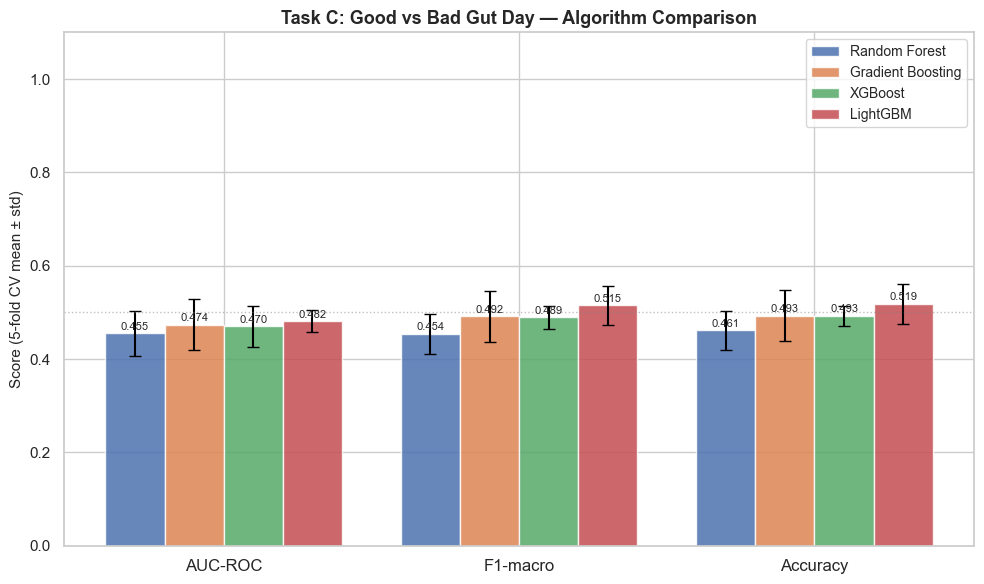

In [20]:
# Task C visualization
names_c   = list(task_c_results.keys())
metrics_c = ['AUC', 'F1', 'Acc']
data_c    = np.array([[task_c_results[n][f'{m}_mean'] for m in metrics_c] for n in names_c])
stds_c    = np.array([[task_c_results[n][f'{m}_std']  for m in metrics_c] for n in names_c])

fig, ax = plt.subplots(figsize=(10, 6))
xc = np.arange(len(metrics_c))
n_alg = len(names_c)
width = 0.8 / n_alg
for i, name in enumerate(names_c):
    offsets = xc + (i - n_alg/2 + 0.5) * width
    ax.bar(offsets, data_c[i], width, yerr=stds_c[i], capsize=4,
           label=name, color=palette_cmp[i], alpha=0.85,
           error_kw=dict(ecolor='black', lw=1.5))
    for j, v in enumerate(data_c[i]):
        ax.text(offsets[j], v+0.003, f'{v:.3f}', ha='center', va='bottom', fontsize=8)
ax.set_xticks(xc); ax.set_xticklabels(['AUC-ROC','F1-macro','Accuracy'], fontsize=12)
ax.set_ylim(0, 1.1); ax.set_ylabel('Score (5-fold CV mean ± std)', fontsize=11)
ax.set_title('Task C: Good vs Bad Gut Day — Algorithm Comparison', weight='bold', fontsize=13)
ax.legend(fontsize=10); ax.axhline(0.5, color='gray', linestyle=':', lw=1, alpha=0.5)
plt.tight_layout(); plt.show()

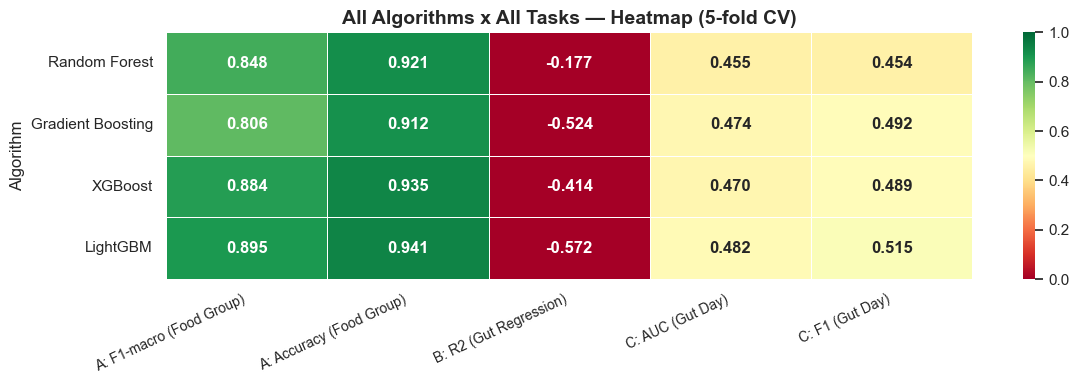


Best algorithm per task:
  A: F1-macro (Food Group): LightGBM (0.8947)
  A: Accuracy (Food Group): LightGBM (0.9408)
  B: R2 (Gut Regression): Random Forest (-0.1770)
  C: AUC (Gut Day): LightGBM (0.4815)
  C: F1 (Gut Day): LightGBM (0.5154)


In [21]:
# Overall comparison heatmap
hmap_rows = []
for name in list(task_a_results.keys()):
    row = {'Algorithm': name}
    row['A: F1-macro (Food Group)']  = task_a_results[name]['F1-macro_mean'] if name in task_a_results else np.nan
    row['A: Accuracy (Food Group)']  = task_a_results[name]['Accuracy_mean']  if name in task_a_results else np.nan
    row['B: R2 (Gut Regression)']    = task_b_results[name]['R2_mean']         if name in task_b_results else np.nan
    row['C: AUC (Gut Day)']          = task_c_results[name]['AUC_mean']         if name in task_c_results else np.nan
    row['C: F1 (Gut Day)']           = task_c_results[name]['F1_mean']           if name in task_c_results else np.nan
    hmap_rows.append(row)
hmap_df = pd.DataFrame(hmap_rows).set_index('Algorithm')

fig, ax = plt.subplots(figsize=(12, max(4, len(hmap_df))))
sns.heatmap(hmap_df, annot=True, fmt='.3f', cmap='RdYlGn',
            vmin=0, vmax=1, linewidths=0.5, ax=ax,
            annot_kws={'size': 12, 'weight': 'bold'})
ax.set_title('All Algorithms x All Tasks — Heatmap (5-fold CV)', weight='bold', fontsize=14)
ax.set_xticklabels(ax.get_xticklabels(), rotation=25, ha='right', fontsize=10)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=11)
plt.tight_layout(); plt.show()

print('\nBest algorithm per task:')
for col in hmap_df.columns:
    best = hmap_df[col].idxmax()
    print(f'  {col}: {best} ({hmap_df.loc[best, col]:.4f})')

---
## Section 8 — SHAP Interpretability

SHAP (SHapley Additive exPlanations) explains *why* the model made each prediction.
- **Higher |SHAP value|** = that feature had more impact on the output
- **Color (beeswarm)**: red = high feature value, blue = low feature value


SHAP is available. Computing explanations...


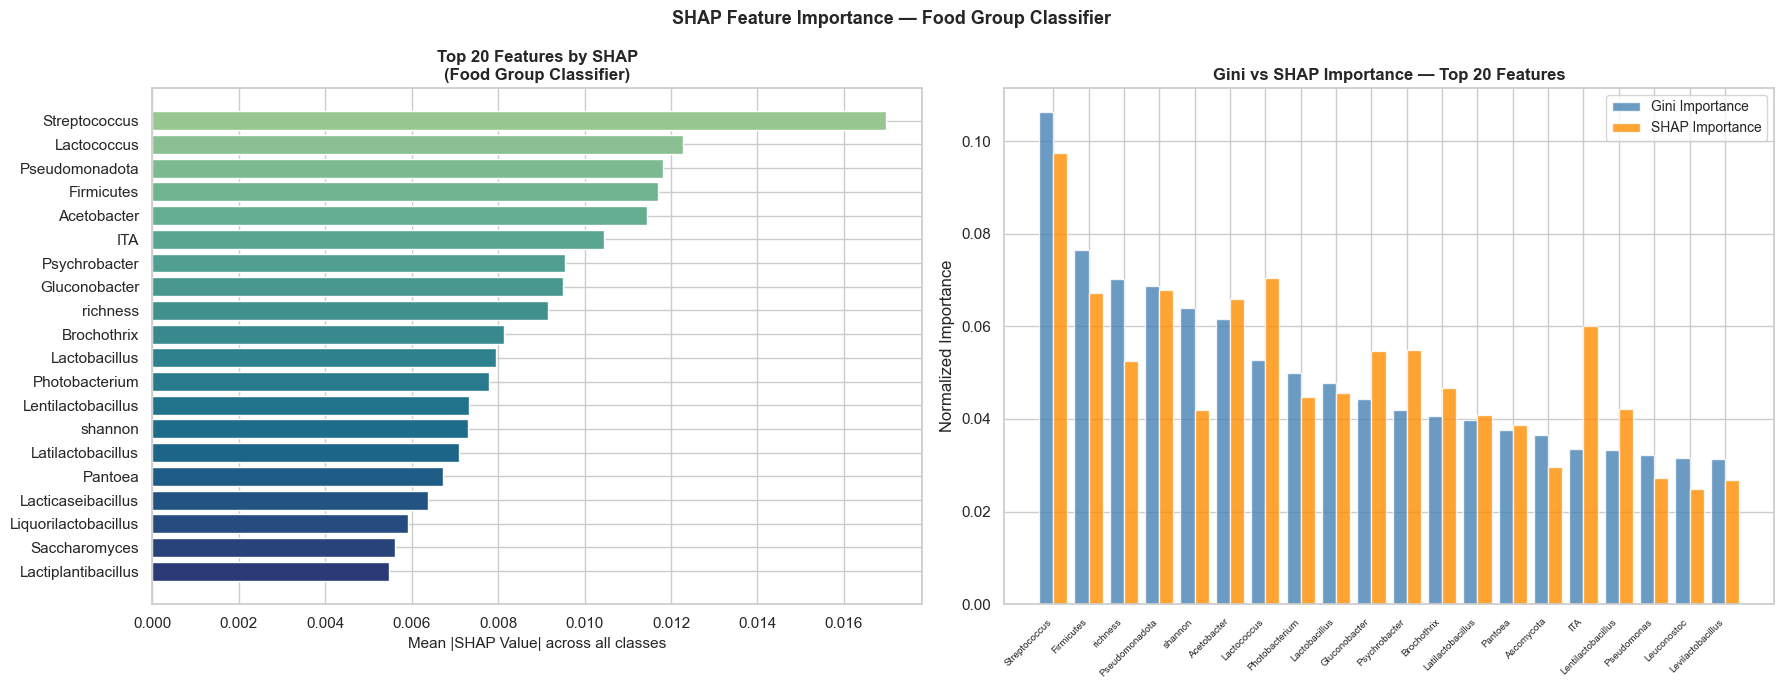

In [22]:
if not SHAP_AVAILABLE:
    print('SHAP not installed. Run: pip install shap')
else:
    print('SHAP is available. Computing explanations...')
    SHAP_SAMPLE = min(300, len(X1_te))
    X1_shap = X1_te.sample(SHAP_SAMPLE, random_state=RANDOM_SEED) if len(X1_te) > SHAP_SAMPLE else X1_te

    # ── Food Group Classifier ──────────────────────────────────────────────
    explainer_cls = shap.TreeExplainer(rf1)
    _raw_shap_cls = explainer_cls.shap_values(X1_shap)

    # Normalize to a list of (n_samples, n_features) arrays, one per class —
    # newer SHAP versions return a single 3D array instead of a list
    n_cls = len(le.classes_)
    if isinstance(_raw_shap_cls, list):
        shap_vals_cls = _raw_shap_cls
    else:
        _arr = np.asarray(_raw_shap_cls)
        if _arr.ndim == 3 and _arr.shape[-1] == n_cls:
            shap_vals_cls = [_arr[:, :, i] for i in range(n_cls)]
        elif _arr.ndim == 3 and _arr.shape[0] == n_cls:
            shap_vals_cls = [_arr[i] for i in range(n_cls)]
        else:
            shap_vals_cls = [_arr]

    # Mean absolute SHAP across classes — overall importance
    mean_abs_shap = np.mean([np.abs(sv) for sv in shap_vals_cls], axis=0)

    fig, axes = plt.subplots(1, 2, figsize=(18, 7))

    # Bar chart of mean |SHAP|
    shap_imp = pd.Series(mean_abs_shap.mean(axis=0), index=X1.columns).sort_values(ascending=False)
    top_shap  = shap_imp.head(20)
    colors_shap = sns.color_palette('crest_r', 20)
    axes[0].barh([short_label(n) for n in top_shap.index[::-1]],
                  top_shap.values[::-1], color=colors_shap)
    axes[0].set_xlabel('Mean |SHAP Value| across all classes', fontsize=11)
    axes[0].set_title('Top 20 Features by SHAP\n(Food Group Classifier)', weight='bold', fontsize=12)

    # Compare SHAP vs Gini importance
    shared_top = list(imp_d1.head(20).index)
    gini_vals  = imp_d1[shared_top].values
    shap_vals_norm = shap_imp[shared_top].values
    shap_vals_norm = shap_vals_norm / shap_vals_norm.sum()
    gini_vals_norm = gini_vals / gini_vals.sum()

    xv = np.arange(len(shared_top))
    axes[1].bar(xv - 0.2, gini_vals_norm, 0.4, label='Gini Importance', color='steelblue', alpha=0.8)
    axes[1].bar(xv + 0.2, shap_vals_norm, 0.4, label='SHAP Importance', color='darkorange', alpha=0.8)
    axes[1].set_xticks(xv)
    axes[1].set_xticklabels([short_label(n) for n in shared_top], rotation=45, ha='right', fontsize=7)
    axes[1].set_ylabel('Normalized Importance')
    axes[1].set_title('Gini vs SHAP Importance — Top 20 Features', weight='bold', fontsize=12)
    axes[1].legend(fontsize=10)

    plt.suptitle('SHAP Feature Importance — Food Group Classifier', weight='bold', fontsize=13)
    plt.tight_layout(); plt.show()

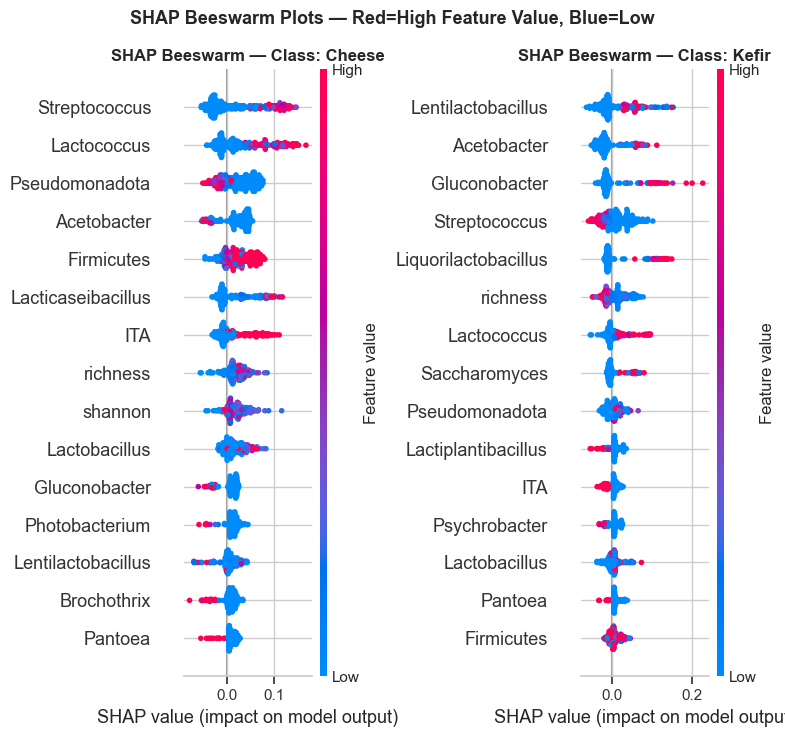

In [23]:
if SHAP_AVAILABLE:
    # Per-class SHAP beeswarm — most predicted class (Cheese = usually class 0 after LE)
    # Find which class index corresponds to 'Cheese'
    cheese_idx = list(le.classes_).index('Cheese') if 'Cheese' in list(le.classes_) else 0

    fig, axes = plt.subplots(1, 2, figsize=(18, 7))

    # Beeswarm for Cheese class
    plt.sca(axes[0])
    shap.summary_plot(shap_vals_cls[cheese_idx], X1_shap,
                      max_display=15, show=False,
                      feature_names=[short_label(c) for c in X1.columns])
    axes[0].set_title(f'SHAP Beeswarm — Class: {le.classes_[cheese_idx]}', weight='bold', fontsize=12)

    # Beeswarm for Kefir or second-most common class
    kefir_idx = list(le.classes_).index('Kefir') if 'Kefir' in list(le.classes_) else 1
    plt.sca(axes[1])
    shap.summary_plot(shap_vals_cls[kefir_idx], X1_shap,
                      max_display=15, show=False,
                      feature_names=[short_label(c) for c in X1.columns])
    axes[1].set_title(f'SHAP Beeswarm — Class: {le.classes_[kefir_idx]}', weight='bold', fontsize=12)

    plt.suptitle('SHAP Beeswarm Plots — Red=High Feature Value, Blue=Low',
                 weight='bold', fontsize=13)
    plt.tight_layout(); plt.show()

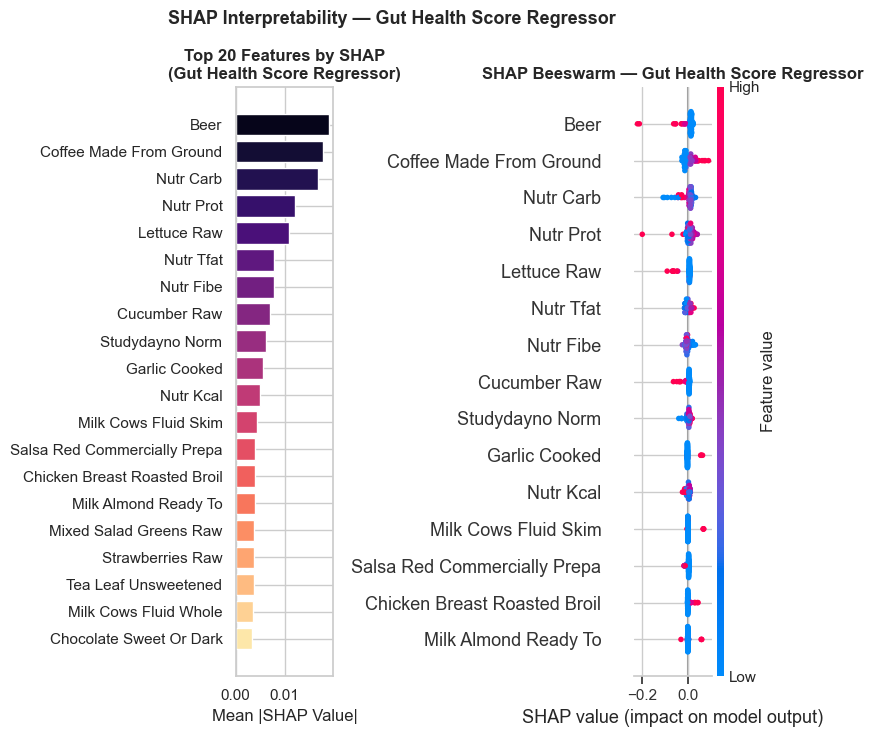

SHAP top 5 food drivers: ['Beer', 'Coffee_made_from_ground_regular', 'nutr_CARB', 'nutr_PROT', 'Lettuce_raw']


In [24]:
if SHAP_AVAILABLE:
    # SHAP for Gut Health Score Regressor
    SHAP_REG_SAMPLE = min(200, len(X_te3))
    X_reg_shap = X_te3.sample(SHAP_REG_SAMPLE, random_state=RANDOM_SEED) \
                  if len(X_te3) > SHAP_REG_SAMPLE else X_te3

    explainer_reg = shap.TreeExplainer(rf_reg)
    _raw_shap_reg = explainer_reg.shap_values(X_reg_shap)
    _arr_reg = np.asarray(_raw_shap_reg)
    if _arr_reg.ndim == 3:
        shap_vals_reg = _arr_reg[:, :, 0] if _arr_reg.shape[-1] == 1 else _arr_reg.mean(axis=-1)
    else:
        shap_vals_reg = _arr_reg

    fig, axes = plt.subplots(1, 2, figsize=(18, 6))

    # Bar chart
    shap_imp_reg = pd.Series(np.abs(shap_vals_reg).mean(axis=0),
                              index=X_full.columns).sort_values(ascending=False)
    top20_reg = shap_imp_reg.head(20)

    def food_label(n):
        return ' '.join(n.replace('_NFS','').split('_')[:4]).title()[:28]

    colors_reg = sns.color_palette('magma_r', 20)
    axes[0].barh([food_label(n) for n in top20_reg.index[::-1]],
                  top20_reg.values[::-1], color=colors_reg)
    axes[0].set_xlabel('Mean |SHAP Value|')
    axes[0].set_title('Top 20 Features by SHAP\n(Gut Health Score Regressor)', weight='bold', fontsize=12)

    # Beeswarm
    plt.sca(axes[1])
    shap.summary_plot(shap_vals_reg, X_reg_shap,
                      max_display=15, show=False,
                      feature_names=[food_label(c) for c in X_full.columns])
    axes[1].set_title('SHAP Beeswarm — Gut Health Score Regressor', weight='bold', fontsize=12)

    plt.suptitle('SHAP Interpretability — Gut Health Score Regressor',
                 weight='bold', fontsize=13)
    plt.tight_layout(); plt.show()
    print('SHAP top 5 food drivers:', list(top20_reg.head(5).index))
else:
    print('Skipping SHAP regressor plot (SHAP not installed)')

---
## Section 9 — FDR Correction on Food Health Rankings

When testing 70+ foods simultaneously, some significant p-values are expected by chance.
We apply the **Benjamini-Hochberg** False Discovery Rate (FDR) correction.

- **p-value**: probability the observed difference occurred by chance
- **q-value (FDR)**: expected fraction of false positives among significant results
- **Volcano plot**: x = effect size (score diff), y = statistical significance (-log10 p)


In [25]:
from scipy.stats import mannwhitneyu

fdr_results = []
for food in food_cols:
    mask  = model_df[food] > 0
    grp_a = model_df.loc[ mask, 'GutHealthScore'].dropna()
    grp_b = model_df.loc[~mask, 'GutHealthScore'].dropna()
    if len(grp_a) < 3 or len(grp_b) < 3:
        continue
    stat, pval = mannwhitneyu(grp_a, grp_b, alternative='two-sided')
    score_diff  = grp_a.mean() - grp_b.mean()
    fdr_results.append(dict(
        food      = food,
        label     = ' '.join(food.replace('_NFS','').split('_')[:4]).title(),
        n_eaten   = len(grp_a),
        score_diff= score_diff,
        pvalue    = pval,
    ))

fdr_df = pd.DataFrame(fdr_results)

# Apply BH FDR correction
if STATSMODELS_AVAILABLE:
    reject, qvals, _, _ = multipletests(fdr_df['pvalue'].values, method='fdr_bh', alpha=0.1)
    fdr_df['qvalue']     = qvals
    fdr_df['FDR_sig']    = reject
else:
    # Manual BH procedure
    n_tests = len(fdr_df)
    sorted_idx = np.argsort(fdr_df['pvalue'].values)
    ranks = np.empty(n_tests); ranks[sorted_idx] = np.arange(1, n_tests+1)
    qvals = fdr_df['pvalue'].values * n_tests / ranks
    qvals = np.minimum.accumulate(qvals[::-1])[::-1]  # monotone
    fdr_df['qvalue']  = qvals
    fdr_df['FDR_sig'] = qvals < 0.1

fdr_df = fdr_df.sort_values('score_diff', ascending=False)
n_sig  = fdr_df['FDR_sig'].sum()
print(f'Total foods tested     : {len(fdr_df)}')
print(f'p < 0.05 (raw)         : {(fdr_df["pvalue"] < 0.05).sum()}')
print(f'FDR q < 0.10 (BH)      : {n_sig}')
print()
if n_sig > 0:
    print('Significant foods after FDR correction:')
    display(fdr_df[fdr_df['FDR_sig']][
        ['label','n_eaten','score_diff','pvalue','qvalue']].round(4))
else:
    print('No foods survive FDR q<0.10 (expected with N=32 participants)')
    print('Top 10 foods by effect size (before FDR):')
    display(fdr_df.head(10)[['label','n_eaten','score_diff','pvalue','qvalue']].round(4))

Total foods tested     : 77
p < 0.05 (raw)         : 0
FDR q < 0.10 (BH)      : 0

No foods survive FDR q<0.10 (expected with N=32 participants)
Top 10 foods by effect size (before FDR):


,label,n_eaten,score_diff,pvalue,qvalue
31,Garlic Cooked,20,0.1603,0.1648,0.8805
34,Ice Cream Regular Flavors,16,0.1540,0.1092,0.8805
12,Carbonated Water Unsweetened,22,0.1399,0.1421,0.8805
59,Rice Brown Cooked Fat,15,0.1363,0.1282,0.8805
36,Kale Cooked From Fresh,15,0.1331,0.2155,0.8805
76,Wine Table White,15,0.1322,0.1976,0.8805
0,Almond Butter,18,0.1212,0.2118,0.8805
53,Orange Juice Canned Bottled,20,0.1159,0.0786,0.8805
48,Nut Mixture With Dried,16,0.1084,0.3672,0.8805
49,Oats Raw,15,0.1041,0.3107,0.8805


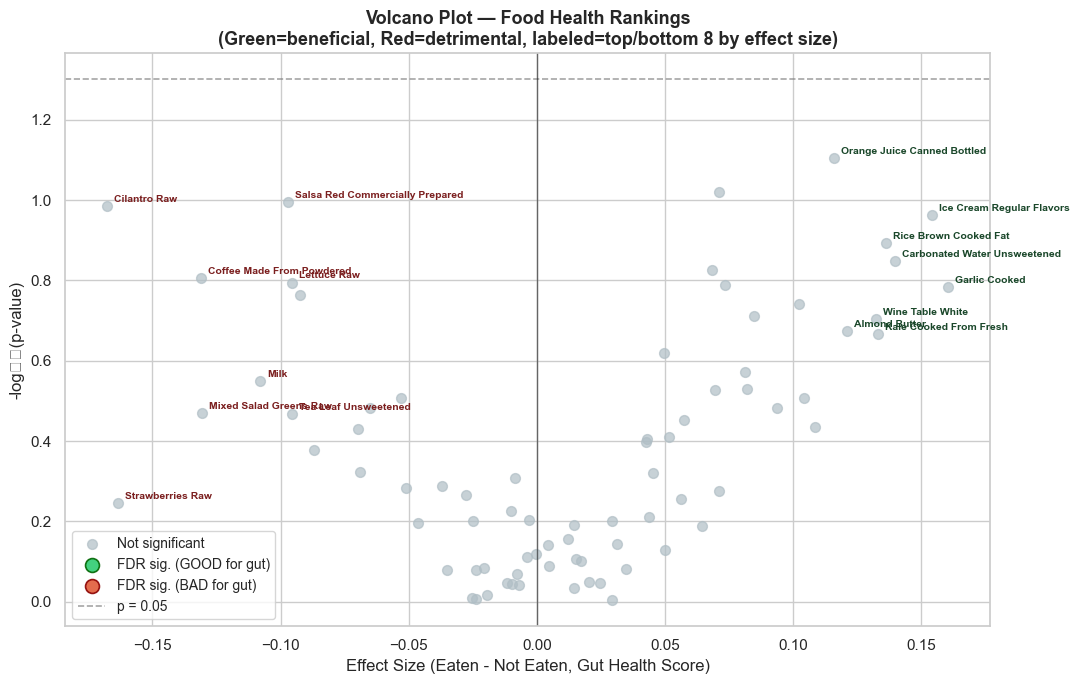

In [26]:
# ── Volcano Plot ──────────────────────────────────────────────────────────
fdr_df['neg_log10_p'] = -np.log10(fdr_df['pvalue'].clip(lower=1e-10))

fig, ax = plt.subplots(figsize=(11, 7))

# Background points
non_sig = fdr_df[~fdr_df['FDR_sig']]
sig_pos = fdr_df[ fdr_df['FDR_sig'] & (fdr_df['score_diff'] > 0)]
sig_neg = fdr_df[ fdr_df['FDR_sig'] & (fdr_df['score_diff'] < 0)]

ax.scatter(non_sig['score_diff'], non_sig['neg_log10_p'],
           c='#B0BEC5', s=50, alpha=0.7, label='Not significant', zorder=2)
ax.scatter(sig_pos['score_diff'], sig_pos['neg_log10_p'],
           c='#2ecc71', s=100, alpha=0.9, edgecolors='darkgreen', lw=1.2,
           label='FDR sig. (GOOD for gut)', zorder=3)
ax.scatter(sig_neg['score_diff'], sig_neg['neg_log10_p'],
           c='#e05c3a', s=100, alpha=0.9, edgecolors='darkred', lw=1.2,
           label='FDR sig. (BAD for gut)', zorder=3)

# Label top 8 by effect size (positive)
for _, row in fdr_df.head(8).iterrows():
    ax.annotate(row['label'], (row['score_diff'], row['neg_log10_p']),
                textcoords='offset points', xytext=(5, 3),
                fontsize=7.5, color='#1a472a', fontweight='bold')

# Label top 8 worst
for _, row in fdr_df.tail(8).iterrows():
    ax.annotate(row['label'], (row['score_diff'], row['neg_log10_p']),
                textcoords='offset points', xytext=(5, 3),
                fontsize=7.5, color='#7b1f1f', fontweight='bold')

# Threshold lines
ax.axhline(-np.log10(0.05), color='gray', linestyle='--', lw=1.2, alpha=0.7,
           label='p = 0.05')
ax.axvline(0, color='black', lw=1, alpha=0.5)

ax.set_xlabel('Effect Size (Eaten - Not Eaten, Gut Health Score)', fontsize=12)
ax.set_ylabel('-log\u2081\u2080(p-value)', fontsize=12)
ax.set_title('Volcano Plot — Food Health Rankings\n'
             '(Green=beneficial, Red=detrimental, labeled=top/bottom 8 by effect size)',
             weight='bold', fontsize=13)
ax.legend(fontsize=10)
plt.tight_layout(); plt.show()

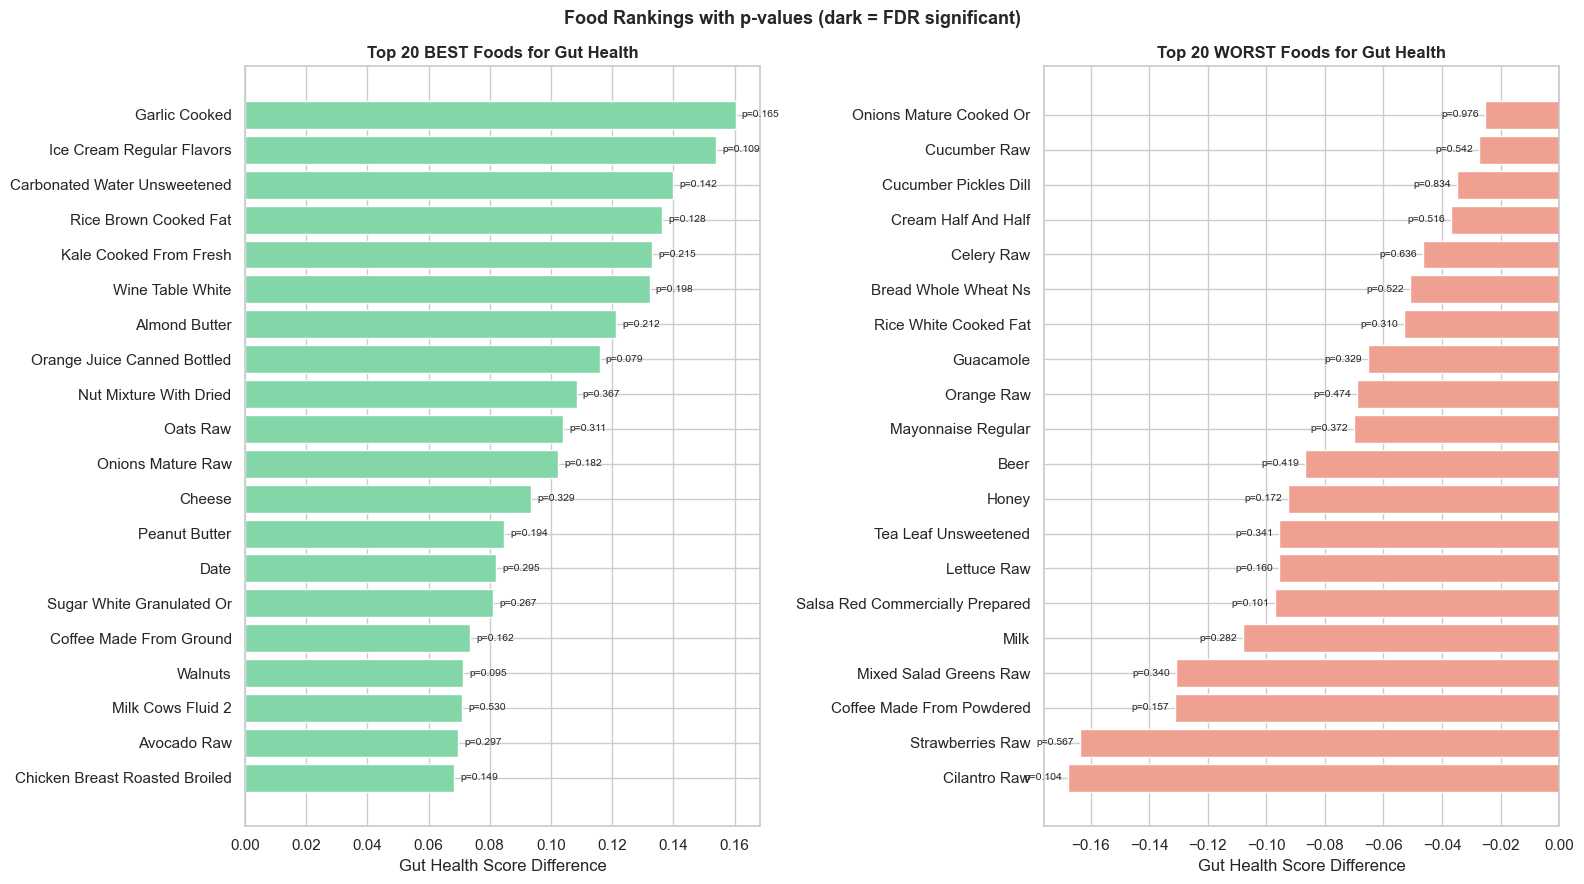

Saved food_ranking_fdr.csv


In [27]:
# ── Full ranked table with p-values ──────────────────────────────────────
display_df = fdr_df[['label','n_eaten','score_diff','pvalue','qvalue','FDR_sig']].copy()
display_df.columns = ['Food','N Eaten','Score Diff','p-value','q-value (FDR)','Significant']
display_df = display_df.sort_values('Score Diff', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 9))

# Top 20 best foods
top20_foods = display_df.head(20)
colors_top  = ['#2ecc71' if sig else '#82d6a8' for sig in top20_foods['Significant']]
axes[0].barh(top20_foods['Food'][::-1], top20_foods['Score Diff'][::-1], color=colors_top[::-1])
axes[0].set_xlabel('Gut Health Score Difference')
axes[0].set_title('Top 20 BEST Foods for Gut Health', weight='bold', fontsize=12)
for i, (_, row) in enumerate(top20_foods[::-1].iterrows()):
    p_str = f'p={row["p-value"]:.3f}' if row['p-value'] >= 0.001 else f'p={row["p-value"]:.2e}'
    axes[0].text(max(row['Score Diff'], 0) + 0.002, i, p_str, va='center', fontsize=7.5)

# Bottom 20 worst foods
bot20_foods = display_df.tail(20).sort_values('Score Diff')
colors_bot  = ['#e05c3a' if sig else '#f0a090' for sig in bot20_foods['Significant']]
axes[1].barh(bot20_foods['Food'], bot20_foods['Score Diff'], color=colors_bot)
axes[1].set_xlabel('Gut Health Score Difference')
axes[1].set_title('Top 20 WORST Foods for Gut Health', weight='bold', fontsize=12)
for i, (_, row) in enumerate(bot20_foods.iterrows()):
    p_str = f'p={row["p-value"]:.3f}' if row['p-value'] >= 0.001 else f'p={row["p-value"]:.2e}'
    axes[1].text(row['Score Diff'] - 0.002, i, p_str, ha='right', va='center', fontsize=7.5)
axes[1].axvline(0, color='black', lw=1)

plt.suptitle('Food Rankings with p-values (dark = FDR significant)', weight='bold', fontsize=13)
plt.tight_layout(); plt.show()

# Save updated ranking with FDR
fdr_df.to_csv(REPO_ROOT / 'food_ranking_fdr.csv', index=False)
print('Saved food_ranking_fdr.csv')

---
## Final Summary — All Results


In [28]:
# Find best model per task
best_a = max(task_a_results, key=lambda k: task_a_results[k]['F1-macro_mean'])
best_b = max(task_b_results, key=lambda k: task_b_results[k]['R2_mean'])
best_c = max(task_c_results, key=lambda k: task_c_results[k]['AUC_mean'])

summary_rows = [
    {'Phase':'Model Comparison','Task':'Food Group (D1)','Best Algorithm':best_a,
     'Key Metric':f'F1-macro = {task_a_results[best_a]["F1-macro_mean"]:.4f}',
     'Note':'10-class food classification from microbiome profile'},
    {'Phase':'Model Comparison','Task':'Gut Health Regression (D2)','Best Algorithm':best_b,
     'Key Metric':f'R2 = {task_b_results[best_b]["R2_mean"]:.4f}',
     'Note':'Predicting gut response from diet'},
    {'Phase':'Model Comparison','Task':'Good/Bad Gut Day (D2)','Best Algorithm':best_c,
     'Key Metric':f'AUC = {task_c_results[best_c]["AUC_mean"]:.4f}',
     'Note':'Binary gut health day classification'},
    {'Phase':'SHAP','Task':'Food Group Classifier','Best Algorithm':'Random Forest',
     'Key Metric':'See beeswarm plots',
     'Note':'Genus-level microbiome taxa drive predictions'},
    {'Phase':'FDR','Task':'Food Ranking','Best Algorithm':'Mann-Whitney + BH',
     'Key Metric':f'{n_sig} sig. foods (q<0.10)',
     'Note':'Small N=32 limits statistical power'},
]
final_df = pd.DataFrame(summary_rows)
print('=' * 80)
print('COMPLETE EVALUATION SUMMARY — ALL PHASES')
print('=' * 80)
display(final_df)

print()
print(f'Best algorithm for food classification : {best_a}')
print(f'Best algorithm for gut regression      : {best_b}')
print(f'Best algorithm for gut day prediction  : {best_c}')

final_df.to_csv(REPO_ROOT / 'evaluation_summary.csv', index=False)
print('\nSaved evaluation_summary.csv')

COMPLETE EVALUATION SUMMARY — ALL PHASES


,Phase,Task,Best Algorithm,Key Metric,Note
0,Model Comparison,Food Group (D1),LightGBM,F1-macro = 0.8947,10-class food classification from microbiome p...
1,Model Comparison,Gut Health Regression (D2),Random Forest,R2 = -0.1770,Predicting gut response from diet
2,Model Comparison,Good/Bad Gut Day (D2),LightGBM,AUC = 0.4815,Binary gut health day classification
3,SHAP,Food Group Classifier,Random Forest,See beeswarm plots,Genus-level microbiome taxa drive predictions
4,FDR,Food Ranking,Mann-Whitney + BH,0 sig. foods (q<0.10),Small N=32 limits statistical power



Best algorithm for food classification : LightGBM
Best algorithm for gut regression      : Random Forest
Best algorithm for gut day prediction  : LightGBM

Saved evaluation_summary.csv
